# Notebook 01: Data Profiling

## Purpose
Evaluate the raw data to identify what needs to be removed or cleaned before analysis. All observations here directly inform the cleaning decisions applied at the end of this notebook.

## Scope
Only the following tables are used in the analysis:
- `orders`
- `order_items`
- `sellers`
- `products`
- `category_translation`

## Key Findings
- 2016 data is excluded from analysis due to an irregular distribution inconsistent with 2017 and 2018. All analysis covers 2017 to 2018 only.
- Some order items contain shipping dates beyond 2018 and are removed as inconsistent records.
- Two product categories (pc_gamer and portateis_cozinha_e_preparadores_de_alimentos) have no English translation and are mapped manually.
- The products table has 610 rows with missing category and dimension data. The order_reviews table has 814 duplicate review IDs. Both are marked as data quality issues but do not affect the core analysis.

In [1]:
# Imports
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

sys.path.insert(0, "..")

from utils.helpers import load_table, check_pk_duplicates

In [2]:
# Import tables
customers = load_table("../raw_data/olist_customers_dataset.csv", "customers")
geolocation = load_table("../raw_data/olist_geolocation_dataset.csv", "geolocation")
order_items = load_table("../raw_data/olist_order_items_dataset.csv", "order_items")
order_payments = load_table("../raw_data/olist_order_payments_dataset.csv", "order_payments")
order_reviews = load_table("../raw_data/olist_order_reviews_dataset.csv", "order_reviews")
orders = load_table("../raw_data/olist_orders_dataset.csv", "orders")
products = load_table("../raw_data/olist_products_dataset.csv", "products")
sellers = load_table("../raw_data/olist_sellers_dataset.csv", "sellers")
category_translation = load_table("../raw_data/product_category_name_translation.csv", "category_translation")


## 1. Data Overview

Quick check of row counts, null counts, duplicate primary keys, and dtype conversions across all 9 tables.

- `order_reviews` has 814 duplicate `review_id` values, meaning multiple reviews share the same ID. This is out of scope for analysis but worth noting as a data quality issue.

> **Note:** The `geolocation` table contains duplicate zip code prefixes mapping to different coordinates. This can be ignored for now since the table is out of scope. However, if it were to be used in further analysis, data cleaning is required.

In [3]:
# show info for each table and verify that the dtypes for each field is correct
tables = {
	"customers": customers,
	"geolocation": geolocation,
	"order_items": order_items,
	"order_payments": order_payments,
	"order_reviews": order_reviews,
	"orders": orders,
	"products": products,
	"sellers": sellers,
	"category_translation": category_translation
}

for name, df in tables.items():
	print(f"=== {name} ===")
	df.info()
	print()


=== customers ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  object
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB

=== geolocation ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  object 
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city  

In [4]:
# check for duplicate primary keys
pk_map = {
	"customers": (customers, ["customer_id"]),
	"geolocation": (geolocation, ["geolocation_zip_code_prefix"]),
	"order_items": (order_items, ["order_id", "order_item_id"]),
	"order_payments": (order_payments, ["order_id", "payment_sequential"]),
	"order_reviews": (order_reviews, ["review_id"]),
	"orders": (orders, ["order_id"]),
	"products": (products, ["product_id"]),
	"sellers": (sellers, ["seller_id"]),
	"category_translation": (category_translation, ["product_category_name"]),
}

for name, (df, pk_cols) in pk_map.items():
    dupes = check_pk_duplicates(df, pk_cols)
    print(f"{name}, {pk_cols}, {dupes}")


customers, ['customer_id'], 0
geolocation, ['geolocation_zip_code_prefix'], 981148
order_items, ['order_id', 'order_item_id'], 0
order_payments, ['order_id', 'payment_sequential'], 0
order_reviews, ['review_id'], 814
orders, ['order_id'], 0
products, ['product_id'], 0
sellers, ['seller_id'], 0
category_translation, ['product_category_name'], 0


## 2. Table Profiling

Detailed profile of the used tables on shape, null counts per column, and unique value counts.

- The `products` table has 610 rows with nulls across category name and dimension fields. All other used tables are fully clean with no missing values.

In [5]:
used_tables = {
	"orders": orders,
	"order_items": order_items,
	"sellers": sellers,
	"products": products,
	"category_translation": category_translation,
}

for name, df in used_tables.items():
	print("=" * 60)
	print(f"TABLE: {name}")
	print("=" * 60)
	print(f"Shape: {df.shape}")

	rows_with_null = df.isnull().any(axis=1).sum()
	rows_with_null_pct = rows_with_null / len(df) * 100
	print(f"Rows with at least 1 null: {rows_with_null:,} ({rows_with_null_pct:.1f}%)")

	print("Dtypes & Null Counts:")
	null_counts = df.isnull().sum()
	for col in df.columns:
		null_pct = null_counts[col] / len(df) * 100
		print(f"\t{col:<35} {str(df[col].dtype):<15} nulls: {null_counts[col]:,} ({null_pct:.1f}%)")

	print("Unique Value Counts:")
	for col in df.select_dtypes(include="object").columns:
		print(f"\t{col}: {df[col].nunique():,} unique values")
	print()

TABLE: orders
Shape: (99441, 8)
Rows with at least 1 null: 2,980 (3.0%)
Dtypes & Null Counts:
	order_id                            object          nulls: 0 (0.0%)
	customer_id                         object          nulls: 0 (0.0%)
	order_status                        object          nulls: 0 (0.0%)
	order_purchase_timestamp            datetime64[ns]  nulls: 0 (0.0%)
	order_approved_at                   datetime64[ns]  nulls: 160 (0.2%)
	order_delivered_carrier_date        datetime64[ns]  nulls: 1,783 (1.8%)
	order_delivered_customer_date       datetime64[ns]  nulls: 2,965 (3.0%)
	order_estimated_delivery_date       datetime64[ns]  nulls: 0 (0.0%)
Unique Value Counts:
	order_id: 99,441 unique values
	customer_id: 99,441 unique values
	order_status: 8 unique values

TABLE: order_items
Shape: (112650, 7)
Rows with at least 1 null: 0 (0.0%)
Dtypes & Null Counts:
	order_id                            object          nulls: 0 (0.0%)
	order_item_id                       int64           nulls:

## 3. Data Validation
Validates the following:
- Primary and Foriegn keys according to table relationships
- Date ranges
- Distributions

**Table relationships**

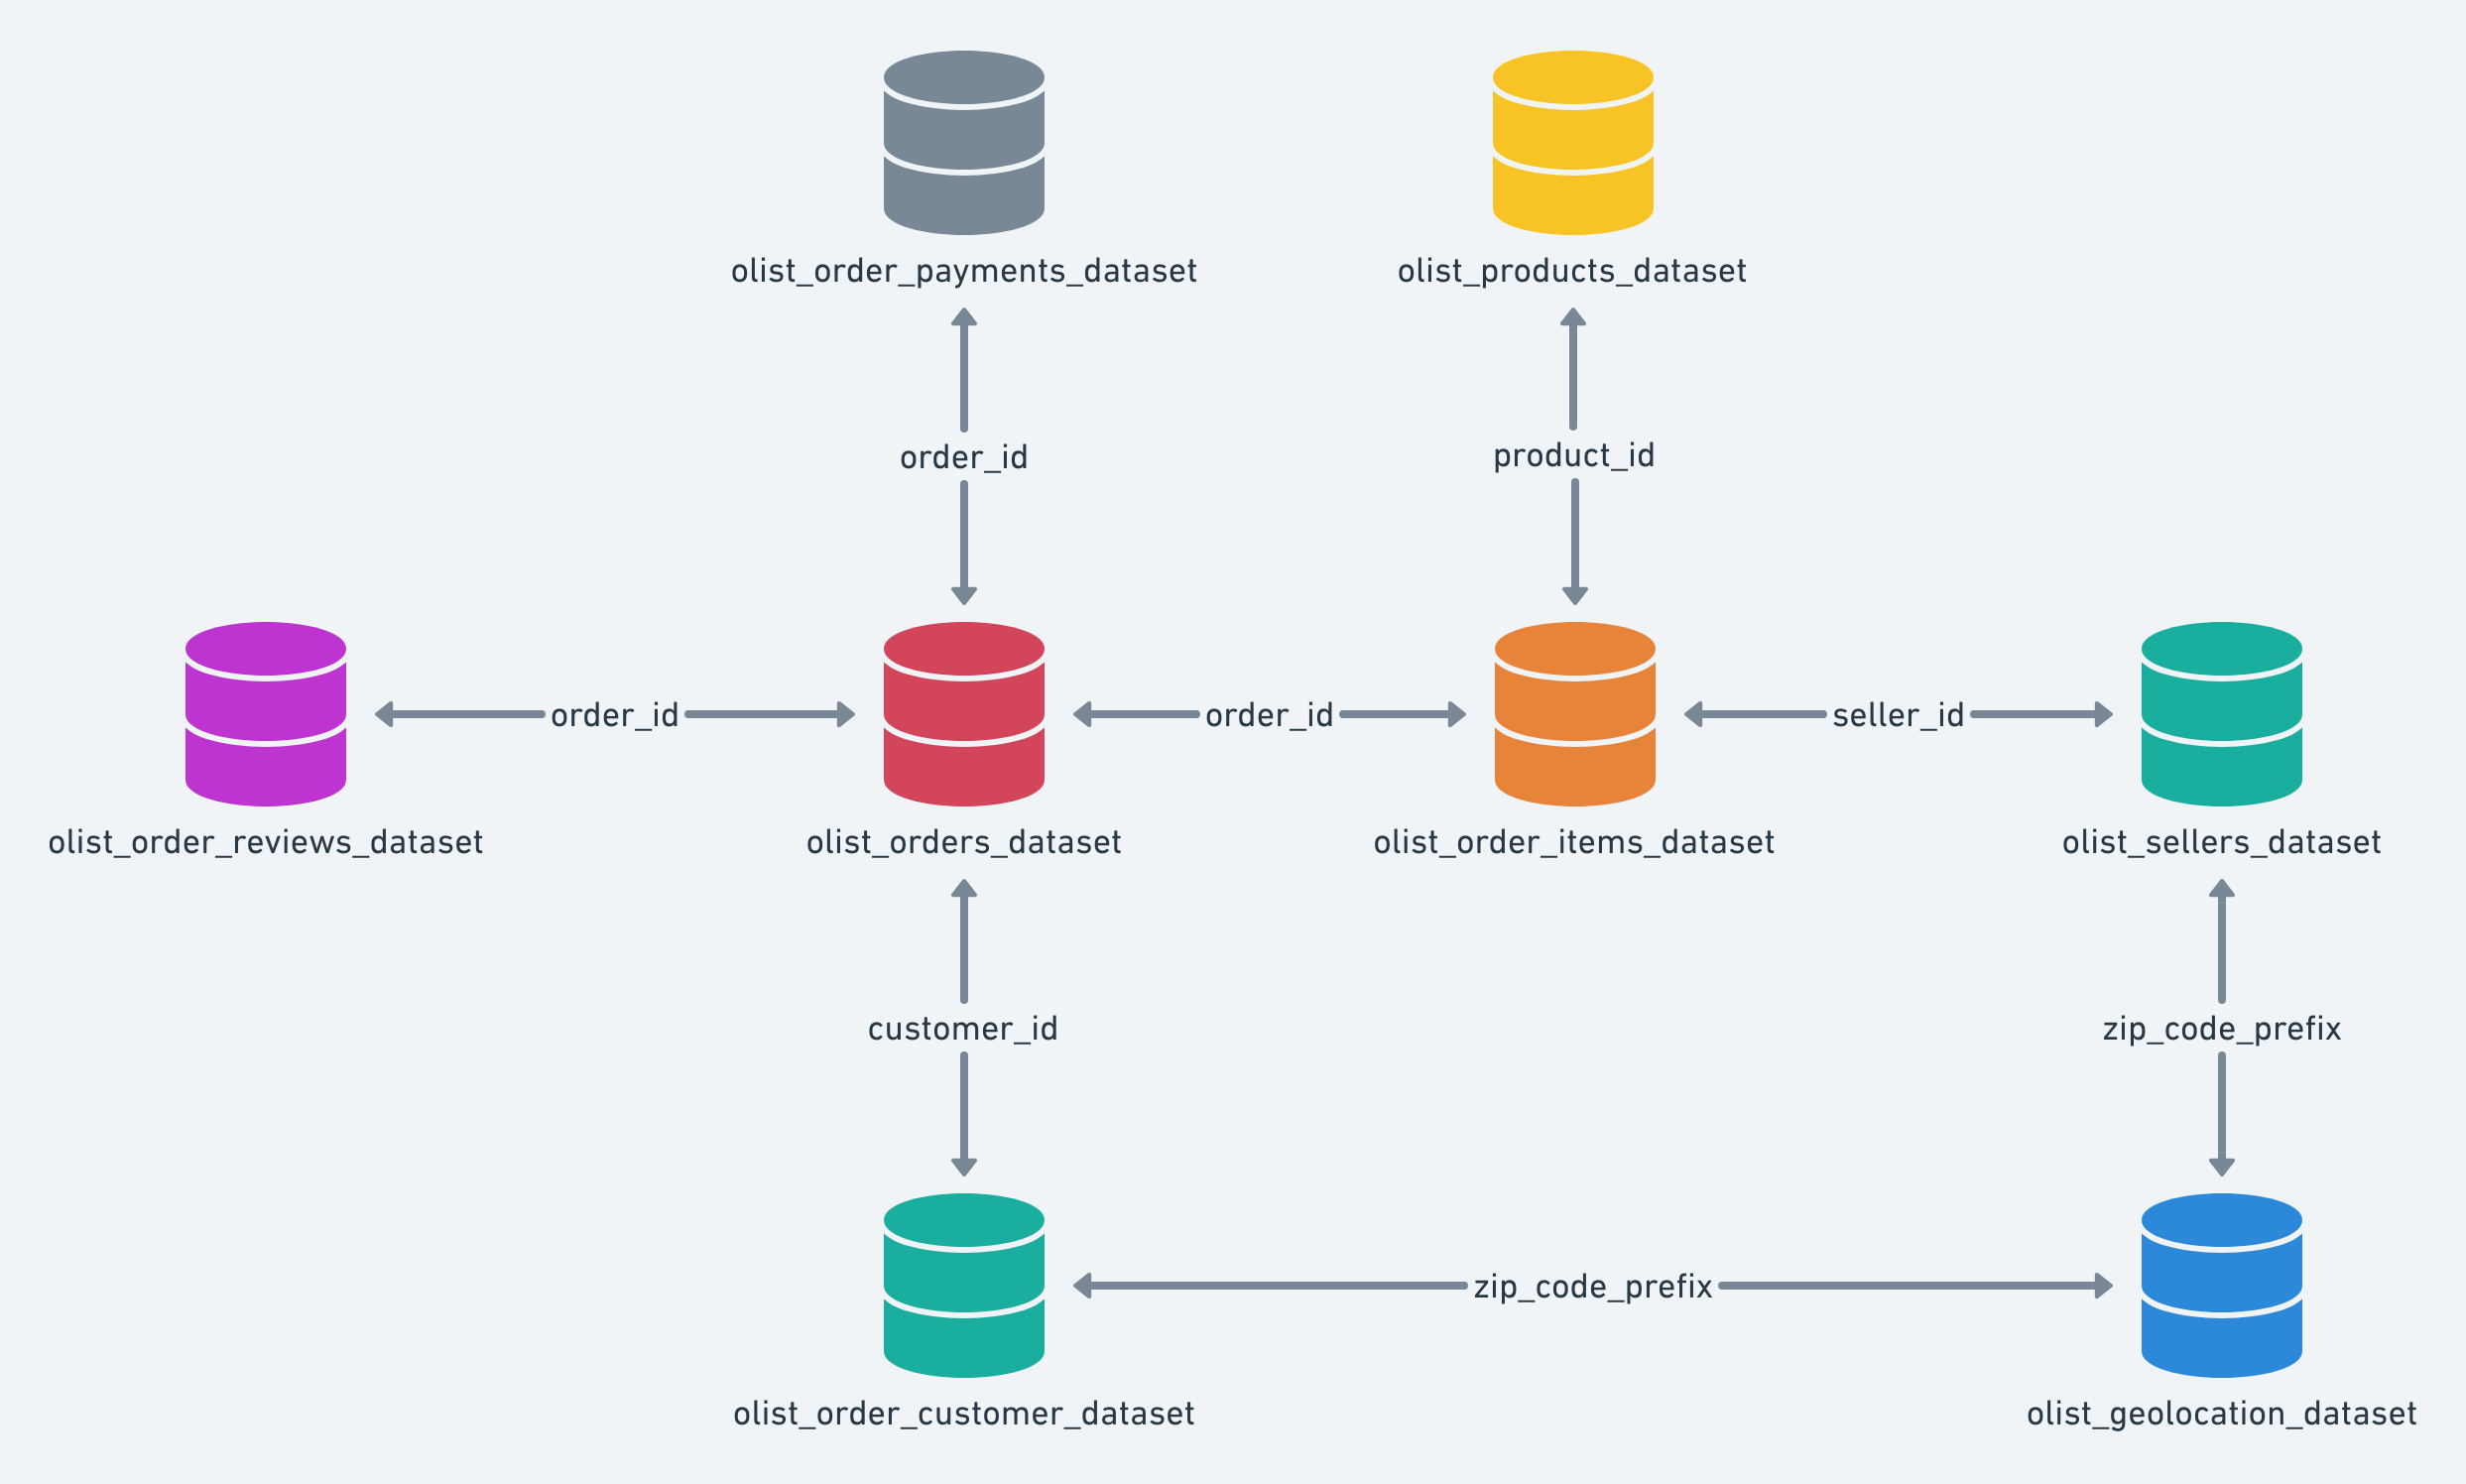

### 3.1 Key Validation
`product_category_name` has 13 records with no matching English translation: specifically `pc_gamer` and `portateis_cozinha_e_preparadores_de_alimentos`. These will be manually mapped in the cleaning step.

In [6]:
# Define Tables/Keys to check
join_checks = [
	("order_items.order_id", order_items["order_id"], orders["order_id"], "orders"),
	("order_items.seller_id", order_items["seller_id"], sellers["seller_id"], "sellers"),
	("order_items.product_id", order_items["product_id"], products["product_id"], "products"),
	("products.product_category_name", products["product_category_name"].dropna(), category_translation["product_category_name"], "category_translation"),
]
for table, fk_col, pk_col, ref_table in join_checks:
	unmatched = ~fk_col.isin(pk_col)
	print(f"Unmatched {table} - {ref_table}: {unmatched.sum()}")


Unmatched order_items.order_id - orders: 0
Unmatched order_items.seller_id - sellers: 0
Unmatched order_items.product_id - products: 0
Unmatched products.product_category_name - category_translation: 13


### 3.2 Date Range Validation
`shipping_limit_date` contains records extending beyond 2018. While a shipping limit date could technically be set at any time, these values are inconsistent with the rest of the dataset and are treated as unclean. They are removed in the cleaning step.

In [7]:
date_cols = {
	"orders": ["order_purchase_timestamp", "order_delivered_carrier_date",
	                "order_delivered_customer_date", "order_estimated_delivery_date"],
	"order_items": ["shipping_limit_date"],
}

for table_name, cols in date_cols.items():
	df = used_tables[table_name]
	print(f"\n  {table_name}:")
	for col in cols:
		print(f"\t{col:<35} {str(df[col].min())} - {str(df[col].max())}")


  orders:
	order_purchase_timestamp            2016-09-04 21:15:19 - 2018-10-17 17:30:18
	order_delivered_carrier_date        2016-10-08 10:34:01 - 2018-09-11 19:48:28
	order_delivered_customer_date       2016-10-11 13:46:32 - 2018-10-17 13:22:46
	order_estimated_delivery_date       2016-09-30 00:00:00 - 2018-11-12 00:00:00

  order_items:
	shipping_limit_date                 2016-09-19 00:15:34 - 2020-04-09 22:35:08


### 3.3 Distribution Validation
Date distributions and numeric field distributions are validated below. 2016 data shows an irregular pattern and will be excluded. Numeric fields are right-skewed with a natural long tail, not data errors.

#### Date Distributions
Although the dataset spans 2016 to 2018, the 2016 record count is very low and several months are entirely missing. The count distribution in 2016 follows an unusual pattern, spiking at month 10 then dropping sharply. These records will be removed from analysis

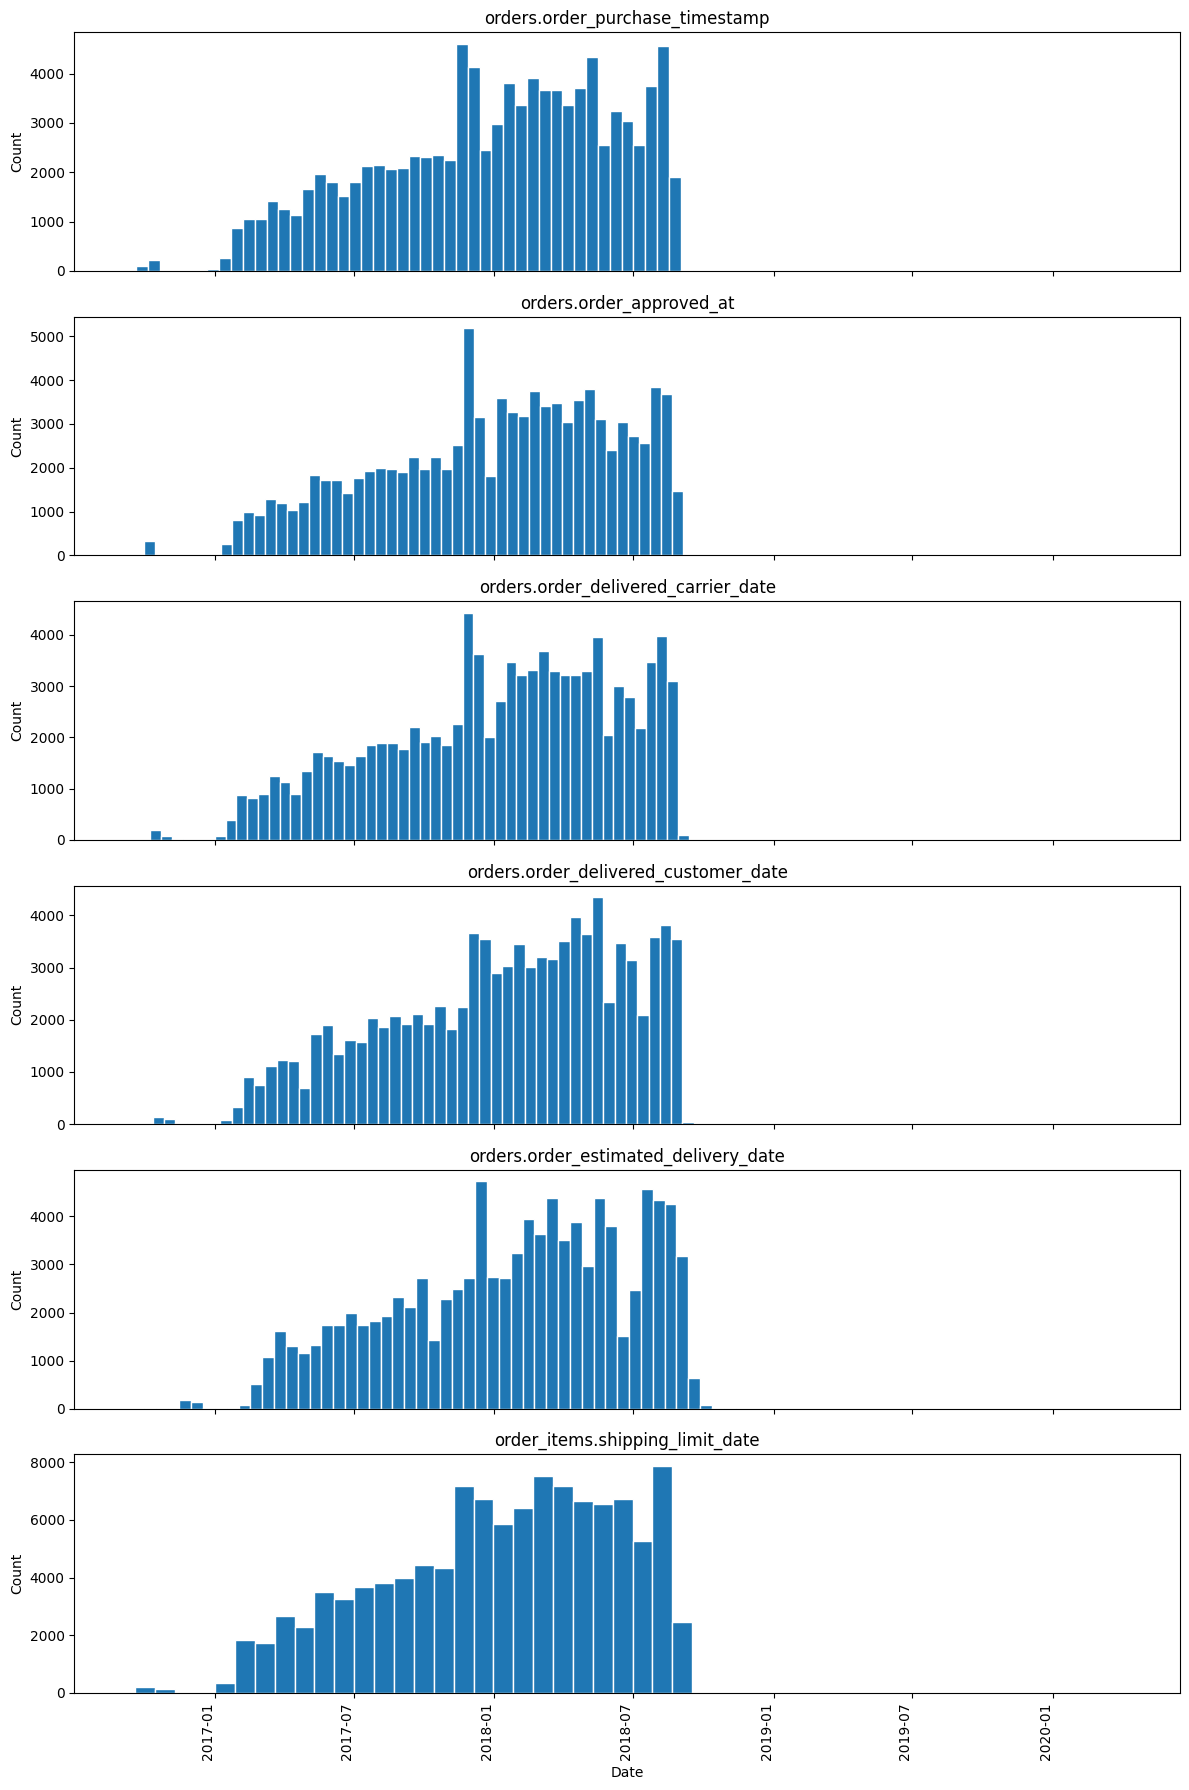

In [8]:
# Plot overall date distribution
date_cols = {
	"orders": [
		"order_purchase_timestamp",
		"order_approved_at",
		"order_delivered_carrier_date",
		"order_delivered_customer_date",
		"order_estimated_delivery_date",
	],
	"order_items": ["shipping_limit_date"],
}

all_cols = [(t, c) for t, cols in date_cols.items() for c in cols]
n = len(all_cols)

fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)

for ax, (table_name, col) in zip(axes, all_cols):
	df = used_tables[table_name]
	series = df[col].dropna()
	ax.hist(series, bins=50, edgecolor="white")
	ax.set_title(f"{table_name}.{col}")
	ax.set_ylabel("Count")

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=90, ha="right")

fig.tight_layout()
plt.show()


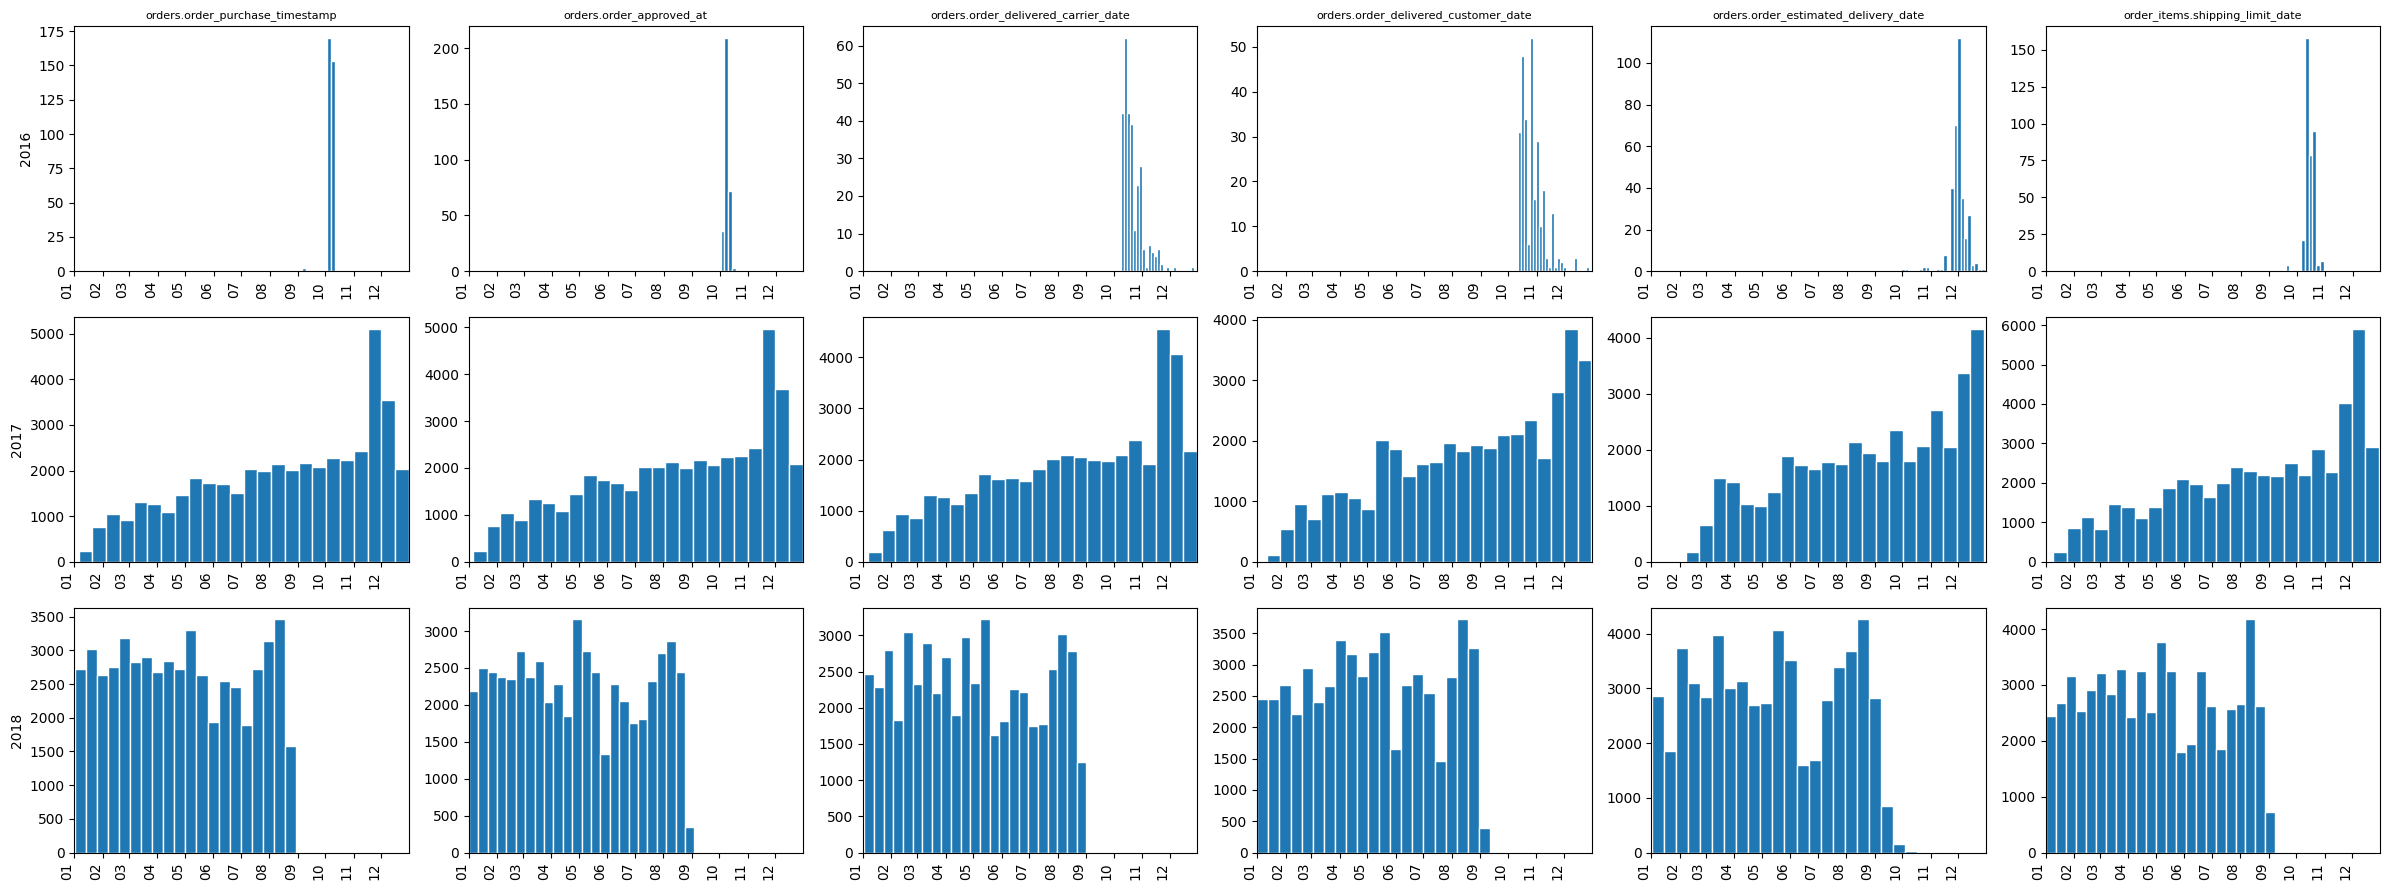

In [9]:
# Plot Distribution by year

years = [2016, 2017, 2018]
all_cols = [(t, c) for t, cols in date_cols.items() for c in cols]
n_cols = len(all_cols)
n_rows = len(years)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharey=False)

for row_idx, year in enumerate(years):
	start = pd.Timestamp(f"{year}-01-01")
	end = pd.Timestamp(f"{year}-12-31")
	for col_idx, (table_name, col) in enumerate(all_cols):
		ax = axes[row_idx][col_idx]
		df = used_tables[table_name]
		series = df[col].dropna()
		year_series = series[(series >= start) & (series <= end)]
		ax.hist(year_series, bins=24, edgecolor="white")
		ax.set_xlim(start, end)
		if col_idx == 0:
			ax.set_ylabel(str(year))
		if row_idx == 0:
			ax.set_title(f"{table_name}.{col}", fontsize=8)
		ax.xaxis.set_major_formatter(mdates.DateFormatter("%m"))
		plt.setp(ax.xaxis.get_majorticklabels(), rotation=90, ha="right")

fig.tight_layout()
plt.show()


#### Numeric Distributions
`price` and `freight_value` are both highly right-skewed. Although some records have unusually high values, the distribution drops off smoothly, suggesting these are part of the natural distribution rather than data entry errors.

order_items.price
  min: 0.85  max: 6735.00  mean: 120.65  median: 74.99


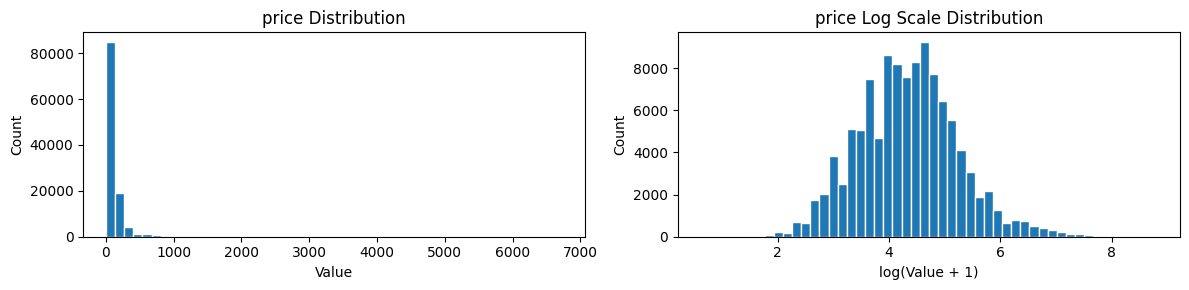

order_items.freight_value
  min: 0.00  max: 409.68  mean: 19.99  median: 16.26


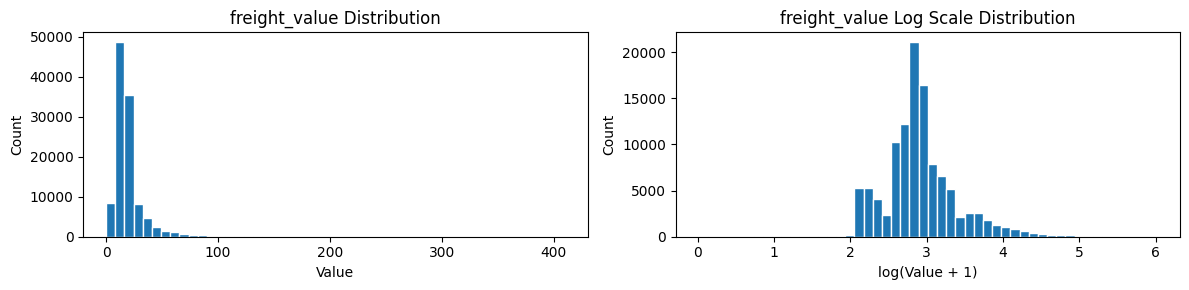

In [10]:
# Numeric Field Distribution
numeric_fields = {
	"order_items": ["price", "freight_value"],
}

for table_name, cols in numeric_fields.items():
	df = used_tables[table_name]
	for col in cols:
		series = df[col].dropna()
		print(f"{table_name}.{col}")
		print(f"  min: {series.min():.2f}  max: {series.max():.2f}  mean: {series.mean():.2f}  median: {series.median():.2f}")


		fig, axes = plt.subplots(1, 2, figsize=(12, 3))

		# Normal distribution
		axes[0].hist(series, bins=50, edgecolor="white")
		axes[0].set_title(f"{col} Distribution")
		axes[0].set_xlabel("Value")
		axes[0].set_ylabel("Count")

		# Log scale distribution
		log_series = series[series > 0]
		axes[1].hist(np.log1p(log_series), bins=50, edgecolor="white")
		axes[1].set_title(f"{col} Log Scale Distribution")
		axes[1].set_xlabel("log(Value + 1)")
		axes[1].set_ylabel("Count")

		fig.tight_layout()
		plt.show()

## 4. Data Cleaning
Check to see how many records will be dropped

### Removal Logic
- Records out of 2017-01-01 to 2018-12-31 are removed
- Records containing nulls on fields that shouldn't be null are removed
- Records that have their parents removed are removed

### Per-table Details
- **orders:** Out-of-range date records removed. Nulls checked only on key identifier columns (`order_id`, `customer_id`, `order_status`, `order_purchase_timestamp`). Delivery date nulls are expected for non-delivered orders and are not checked here.
- **order_items:** Cascaded from orders items whose parent order was removed are also dropped. Items with an out-of-range `shipping_limit_date` are additionally dropped.
- **products:** Any row with a null in any field is dropped. This removes the 610 rows missing `product_category_name` and dimension data.
- **sellers:** No changes. No date columns and no nulls.
- **category_translation:** No changes. No nulls. Two missing categories (`pc_gamer`, `portateis_cozinha_e_preparadores_de_alimentos`) are added manually in the pipeline.

In [11]:
DATE_MIN = pd.Timestamp("2017-01-01")
DATE_MAX = pd.Timestamp("2018-12-31")


def out_of_range_mask(df, cols):
	"""Returns a boolean mask of rows where any date column is outside [DATE_MIN, DATE_MAX]."""
	mask = pd.Series(False, index=df.index)
	for col in cols:
		valid = df[col].notna()
		mask |= valid & ((df[col] < DATE_MIN) | (df[col] > DATE_MAX))
	return mask

def cascade(df, valid_ids):
	return df[df["order_id"].isin(valid_ids)]

In [12]:
#ORDERS
orders_oor_mask = out_of_range_mask(orders, date_cols["orders"])

NULL_COLS = ["order_id", "customer_id", "order_status", "order_purchase_timestamp"]
orders_null_mask = orders[NULL_COLS].isnull().any(axis=1)

orders_remove = orders_oor_mask | orders_null_mask

orders_clean = orders[~orders_remove]

#ITEMS
items_clean = cascade(order_items, orders_clean["order_id"])
items_clean = items_clean[~out_of_range_mask(items_clean, date_cols["order_items"])]

# PRODUCTS
products_clean = products.dropna()



#SELLER/TRANSLATION
results = {
	"orders": {"pre": len(orders), "post": len(orders_clean)},
	"order_items": {"pre": len(order_items), "post": len(items_clean)},
	"products": {"pre": len(products), "post": len(products_clean)},
	"sellers": {"pre": len(sellers), "post": len(sellers)},
	"category_translation": {"pre": len(category_translation), "post": len(category_translation)},
}

col_w = 25
print(f"{'Table':<{col_w}} {'Pre':>8}  {'Post':>8} {'%':>6}")
print("-" * 55)
for name, r in results.items():
	post_pct = r["post"] / r["pre"] * 100
	print(f"{name:<{col_w}} {r['pre']:>8,}  {r['post']:>8,} {post_pct:>5.1f}%")


Table                          Pre      Post      %
-------------------------------------------------------
orders                      99,441    99,112  99.7%
order_items                112,650   112,276  99.7%
products                    32,951    32,340  98.1%
sellers                      3,095     3,095 100.0%
category_translation            71        71 100.0%
